# import需要的函式庫

In [1]:
import sys #1.implement
import pdb
import pprint
import logging
import os
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils import data
import numpy as np
import tqdm.auto as tqdm
from pathlib import Path
from argparse import Namespace
#sys.path.append('../fairseq')  # 添加 src 到 Python 搜索路徑
from fairseq import utils

import matplotlib.pyplot as plt

2024-12-06 19:49:09 | INFO | fairseq.tasks.text_to_speech | Please install tensorboardX: pip install tensorboardX
2024-12-06 19:49:10 | WARNING | xformers | A matching Triton is not available, some optimizations will not be enabled.
Error caught was: No module named 'triton'
2024-12-06 19:49:10 | WARNING | xformers | Triton is not available, some optimizations will not be enabled.
This is just a warning: triton is not available


# 種子設定

In [ ]:
#確保在使用隨機數的過程中，模型的結果可以被重現 
#Some PyTorch operations may use random numbers """"internally"""".

seed = 73
random.seed(seed) 
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  
np.random.seed(seed)  #Random number generators in other libraries
torch.backends.cudnn.benchmark = False
"""
每遇到一個不同shape的tensor會重新測試最快的卷積算法，每次執行程式都會重新測試，但所選算法會受benchmarking noise and different hardware影響，導致結果不一致。將其設置為False可以確保每次執行程式都使用相同的算法，從而提高結果的可重現性。
"""
torch.backends.cudnn.deterministic = True 
"""
讓所選算法是deterministic(輸入相同則輸出必相同的算法)
"""

# 資料集介紹

## 訓練資料
### no m
    - 原始資料量: 100,000句      
    - 處理後資料: 100,000句 
    - src: 0.2212, 0.7689, 0.0001...
    - tgt: SiO2_20, Ag_10, Al2O3_101...
    - data_path: databin
    - spm: spm8000, spm20000(增大不一定更好)
    - 問題：句子太長
    - solution: 1. src用代號(小數第三位) 2. tgt用代號 3.改用transformer(Rnn不擅長long sequence，而且多頭也比單頭好) 

### m
    - 原始資料量: 100,000句      
    - 處理後資料: 100,000句 
    - src: Ac, Aw, Bo... (用 A-Z, a-z ASCII碼來編碼，精度改為小數點後第三位)
    - tgt: a_20, l_10, h_101... (用 a, l, h, s代替化學式)
    - data_path: databinm
    - spm: spm1000m(顯然句子變簡單，所以字典也跟著變小)
    - 問題：1.句子變短但spmmodel會把大小寫當成一樣，如何解決?(目前不知道) 2.BLEU評估無法看出重建好壞，雖然修正之後BLEU從10->14
    - solution: 1. src直接用數字(小數第三位) 2. 增加訓練資料 3. 增加embedding_dim 4.把N調大 5.增加頭數目 
### m6
    - 原始資料量: 1,000,000句      
    - 處理後資料: 1,000,000句 
    - src: 0.123, 0.002, 0.101... (精度改為小數點後第三位)
    - tgt: a_20, l_10, h_10.1... (用 a, l, h, s代替化學式) ex: l_87.8-> 材料為Al2O3，厚度為87.8nm
    - data_path: databinm6
    - spm: spm8000m6(顯然句子變簡單，所以字典也跟著變小)
    - 問題：厚度會限制頻譜多樣性
    - solution: 把al2o3, hfo2, sio2的範圍加大

### mm6
    - 原始資料量: 1,000,000句      
    - 處理後資料: 1,000,000句 
    - src: 0.123, 0.002, 0.101... (精度改為小數點後第三位)
    - tgt: a_20, l_108.3, h_104.3... (把al2o3, hfo2, sio2的範圍加大，懷疑厚度會限制頻譜多樣性)
    - data_path: databinmm6
    - spm: spm8000mm6

## 測試資料
- 資料量: 1,0000句

## 設定src_lang和tgt_lang

In [3]:
src_lang = 'src'# T sequence
tgt_lang = 'tgt'# structure sequence

#data_prefix = f'{prefix}/train_dev.raw'
#test_prefix = f'{prefix}/test.raw'

In [4]:

prefix = './'
prefix = Path(prefix)

## 切出 train/valid set，並分出src, tgt(for train, test, valid)。

In [81]:
import os
import random

# 設定參數
valid_ratio = 0.01  # 驗證集比例，1%
train_ratio = 1 - valid_ratio

# 輸入檔案名稱
train_file = 'trainmm6.txt'
test_file = 'testmm6.txt'

# 輸出檔案名稱
train_src_file = 'trainmm6.clean.src'
train_tgt_file = 'trainmm6.clean.tgt'
valid_src_file = 'validmm6.clean.src'
valid_tgt_file = 'validmm6.clean.tgt'
test_src_file = 'testmm6.clean.src'
test_tgt_file = 'testmm6.clean.tgt'

# 檢查檔案是否已經存在
if (os.path.exists(train_src_file) and os.path.exists(train_tgt_file) and
    os.path.exists(valid_src_file) and os.path.exists(valid_tgt_file)):
    print('train/valid splits exist. Skipping split.')
else:
    # 分割 train.txt 成 train 和 valid 集
    with open(train_file, 'r') as file:
        line_num = sum(1 for _ in file) // 2  # 每組資料有兩行

    # 建立隨機標籤並打亂
    labels = list(range(line_num))
    random.shuffle(labels)

    # 開啟輸出檔案
    train_src_out = open(train_src_file, 'w')
    train_tgt_out = open(train_tgt_file, 'w')
    valid_src_out = open(valid_src_file, 'w')
    valid_tgt_out = open(valid_tgt_file, 'w')

    # 初始化計數器
    count = 0

    # 分割資料
    with open(train_file, 'r') as file:
        while True:
            # 讀取 target 句子和 src 句子（每組兩行）
            target_line = file.readline().strip()
            src_line = file.readline().strip()

            # 如果檔案已經結束，跳出迴圈
            if not target_line or not src_line:
                break

            # 根據隨機標籤分割資料
            if labels[count] / line_num < train_ratio:
                # 寫入訓練集
                train_tgt_out.write(target_line + '\n')
                train_src_out.write(src_line + '\n')
            else:
                # 寫入驗證集
                valid_tgt_out.write(target_line + '\n')
                valid_src_out.write(src_line + '\n')

            count += 1

    # 關閉輸出檔案
    train_src_out.close()
    train_tgt_out.close()
    valid_src_out.close()
    valid_tgt_out.close()

    print('Train and validation data split complete.')

    # 分割 test.txt 成 test.clean.src.txt 和 test.clean.tgt.txt
    with open(test_file, 'r') as file:
        test_src_out = open(test_src_file, 'w')
        test_tgt_out = open(test_tgt_file, 'w')

        while True:
            # 讀取 target 句子和 src 句子（每組兩行）
            target_line = file.readline().strip()
            src_line = file.readline().strip()

            # 如果檔案已經結束，跳出迴圈
            if not target_line or not src_line:
                break

            # 寫入測試集
            test_tgt_out.write(target_line + '\n')
            test_src_out.write(src_line + '\n')

        # 關閉測試集輸出檔案
        test_src_out.close()
        test_tgt_out.close()

    print('Test data split complete.')


Train and validation data split complete.
Test data split complete.


## Subword Units 

- 使用 [sentencepiece](#kudo-richardson-2018-sentencepiece) 套件
- 用 unigram 

In [82]:
import sentencepiece as spm##train the subword model using trainm6.clean and validm6.clean
vocab_size = 8000
if (prefix/f'spm{vocab_size}mm6.model').exists():
    print(f'{prefix}/spm{vocab_size}mm6.model exists. skipping spm_train.')
else:
    spm.SentencePieceTrainer.train(
        input=','.join([f'{prefix}/trainmm6.clean.{src_lang}',
                        f'{prefix}/validmm6.clean.{src_lang}',
                        f'{prefix}/trainmm6.clean.{tgt_lang}',
                        f'{prefix}/validmm6.clean.{tgt_lang}']),
        model_prefix=prefix/f'spm{vocab_size}mm6',
        vocab_size=vocab_size,
        character_coverage=1,
        model_type='unigram', # 'bpe' 也可
        input_sentence_size=1e6,
        shuffle_input_sentence=True,
        normalization_rule_name='nmt_nfkc_cf',
    )

: 

: 

### for train, valid, test

In [7]:
import sentencepiece as spm
vocab_size = 8000
#將原檔案用spm字典的單位詞來表示
#train.clean.src -> train.src; test.clean.src -> test.src; train.clean.tgt -> train.tgt; ...
spm_model = spm.SentencePieceProcessor(model_file=str(prefix/f'spm{vocab_size}mm6.model'))#apply the model to generate 6 files: train.src, train.tgt, valid.src, valid.tgt, test.src, test.tgt
in_tag = {#匯入檔案名稱
    'train': 'trainmm6.clean',
    'valid': 'validmm6.clean',
    'test': 'testmm6.clean',
}
for split in ['train', 'valid', 'test']:
    for lang in [src_lang, tgt_lang]:
        out_path = prefix/f'{split}mm6.{lang}'#匯出檔案路徑名稱
        if out_path.exists():
            print(f"{out_path} exists. skipping spm_encode.")
        else:
            with open(prefix/f'{split}mm6.{lang}', 'w', encoding='utf-8') as out_f:
                with open(prefix/f'{in_tag[split]}.{lang}', 'r', encoding='utf-8') as in_f:
                    for line in in_f:
                        line = line.strip()
                        tok = spm_model.encode(line, out_type=str)
                        #print(tok)
                        print(' '.join(tok), file=out_f)

trainmm6.src exists. skipping spm_encode.
trainmm6.tgt exists. skipping spm_encode.
validmm6.src exists. skipping spm_encode.
validmm6.tgt exists. skipping spm_encode.
testmm6.src exists. skipping spm_encode.
testmm6.tgt exists. skipping spm_encode.


### for ideal

In [165]:
#先準備好ideal.clean.src(.txt檔)
#將原檔案用spm字典的單位詞來表示
#ideal.clean.src -> ideal.src
import sentencepiece as spm
vocab_size = 8000


spm_model = spm.SentencePieceProcessor(model_file=str(prefix/f'spm{vocab_size}mm6.model'))#apply the model to generate 6 files: train.src, train.tgt, valid.src, valid.tgt, test.src, test.tgt
in_tag = {#匯入檔案名稱
    'idealmm6_3': 'ideal3.clean',
}
for split in ['idealmm6_3']:
    for lang in [src_lang]:
        out_path = prefix/f'{split}.{lang}'#匯出檔案路徑名稱: idealm6.src
        if out_path.exists():
            print(f"{out_path} exists. skipping spm_encode.")
        else:
            with open(prefix/f'{split}.{lang}', 'w', encoding='utf-8') as out_f:#打開輸出檔案準備寫入
                with open(prefix/f'{in_tag[split]}.{lang}', 'r', encoding='utf-8') as in_f:#打開輸入檔案
                    for line in in_f:
                        line = line.strip()
                        tok = spm_model.encode(line, out_type=str)
                        #print(tok)
                        print(' '.join(tok), file=out_f)

## 用 fairseq 將資料轉為 binary

In [5]:
prefix = Path('./')  # 指向資料夾路徑，這裡假設資料儲存在 './DATA/processed'
dataset_name = 'my_dataset'  # 您的數據集名稱
data_dir = './'


### for train/valid/test

In [ ]:
binpath = Path('./data-binmm6')#除了轉成bin以外，也用數字重新代換單位詞
if binpath.exists():
    print(binpath, "exists, will not overwrite!")
else:
    !python -m fairseq_cli.preprocess \
        --source-lang {src_lang}\
        --target-lang {tgt_lang}\
        --trainpref {prefix/'trainmm6'}\
        --validpref {prefix/'validmm6'}\
        --testpref {prefix/'testmm6'}\
        --destdir {binpath}\
        --joined-dictionary\
        --workers 2


2024-12-04 09:50:56 | INFO | fairseq.tasks.text_to_speech | Please install tensorboardX: pip install tensorboardX
2024-12-04 09:50:56 | WARNING | xformers | A matching Triton is not available, some optimizations will not be enabled.
Error caught was: No module named 'triton'
2024-12-04 09:50:56 | WARNING | xformers | Triton is not available, some optimizations will not be enabled.
This is just a warning: triton is not available
2024-12-04 09:50:58 | INFO | fairseq_cli.preprocess | Namespace(no_progress_bar=False, log_interval=100, log_format=None, log_file=None, aim_repo=None, aim_run_hash=None, tensorboard_logdir=None, wandb_project=None, azureml_logging=False, seed=1, cpu=False, tpu=False, bf16=False, memory_efficient_bf16=False, fp16=False, memory_efficient_fp16=False, fp16_no_flatten_grads=False, fp16_init_scale=128, fp16_scale_window=None, fp16_scale_tolerance=0.0, on_cpu_convert_precision=False, min_loss_scale=0.0001, threshold_loss_scale=None, amp=False, amp_batch_retries=2, amp

### for ideal

In [167]:
binpath = Path('./data-binmm6')#除了轉成bin以外，也用數字重新代換單位詞?
!python -m fairseq_cli.preprocess \
        --source-lang src \
        --only-source \
        --srcdict {binpath/'dict.src.txt'} \
        --testpref {prefix/'idealmm6_3'} \
        --destdir {binpath} \
        --workers 2


2024-12-05 13:46:43 | INFO | fairseq.tasks.text_to_speech | Please install tensorboardX: pip install tensorboardX
2024-12-05 13:46:43 | WARNING | xformers | A matching Triton is not available, some optimizations will not be enabled.
Error caught was: No module named 'triton'
2024-12-05 13:46:43 | WARNING | xformers | Triton is not available, some optimizations will not be enabled.
This is just a warning: triton is not available
2024-12-05 13:46:43 | INFO | fairseq_cli.preprocess | Namespace(no_progress_bar=False, log_interval=100, log_format=None, log_file=None, aim_repo=None, aim_run_hash=None, tensorboard_logdir=None, wandb_project=None, azureml_logging=False, seed=1, cpu=False, tpu=False, bf16=False, memory_efficient_bf16=False, fp16=False, memory_efficient_fp16=False, fp16_no_flatten_grads=False, fp16_init_scale=128, fp16_scale_window=None, fp16_scale_tolerance=0.0, on_cpu_convert_precision=False, min_loss_scale=0.0001, threshold_loss_scale=None, amp=False, amp_batch_retries=2, amp

# 實驗參數設置

In [6]:
config = Namespace(
    datadir = "./data-binmm6",
    savedir = "./checkpoints/transformermm6_vocab=8000,EN=6,Ehead=8,DN=6,Dhead=8,emb_dim=1024",
    source_lang = "src",
    target_lang = "tgt",
    
    # cpu threads when fetching & processing data.
    num_workers=1,  
    # batch size in terms of tokens. gradient accumulation increases the effective batchsize.
    max_tokens=8192,
    accum_steps=2,
    
    # the lr s calculated from Noam lr scheduler. you can tune the maximum lr by this factor.
    lr_factor=2.,
    lr_warmup=4000,
    
    # clipping gradient norm helps alleviate gradient exploding
    clip_norm=1.0,
    
    # maximum epochs for training
    max_epoch=30,
    start_epoch=1,
    
    # beam size for beam search
    beam=5, 
    # generate sequences of maximum length ax + b, where x is the source length
    max_len_a=1.2, 
    max_len_b=10,
    # when decoding, post process sentence by removing sentencepiece symbols.
    #post_process = "sentencepiece",
    post_process = "sentencepiece",
    # checkpoints
    keep_last_epochs=5,
    resume=None, # if resume from checkpoint name (under config.savedir)
    
    # logging
    use_wandb=False,
)

# Logging
- logging 套件紀錄一般訊息
- wandb 紀錄訓練過程 loss, weight 等等

In [7]:
logging.basicConfig(
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
    level="INFO", # "DEBUG" "WARNING" "ERROR"
    stream=sys.stdout,
)
proj = "seq2seq"
logger = logging.getLogger(proj)
if config.use_wandb:
    import wandb
    wandb.init(project=proj, name=Path(config.savedir).stem, config=config)

# CUDA環境設置設置

In [8]:
cuda_env = utils.CudaEnvironment()
utils.CudaEnvironment.pretty_print_cuda_env_list([cuda_env])
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

2024-12-06 19:50:29 | INFO | fairseq.utils | ***********************CUDA enviroments for all 1 workers***********************
2024-12-06 19:50:29 | INFO | fairseq.utils | rank   0: capabilities =  8.6  ; total memory = 4.000 GB ; name = NVIDIA GeForce RTX 3050 Laptop GPU      
2024-12-06 19:50:29 | INFO | fairseq.utils | ***********************CUDA enviroments for all 1 workers***********************


# 讀取資料集

## 借用 fairseq 的 TranslationTask

In [9]:
from fairseq.tasks.translation import TranslationConfig, TranslationTask

## setup task
task_cfg = TranslationConfig(
    data=config.datadir,
    source_lang=config.source_lang,
    target_lang=config.target_lang,
    train_subset="train",
    required_seq_len_multiple=8,
    dataset_impl="mmap",
    upsample_primary=1,
)
task = TranslationTask.setup_task(task_cfg)

2024-12-06 19:50:32 | INFO | fairseq.tasks.translation | [src] dictionary: 8000 types
2024-12-06 19:50:32 | INFO | fairseq.tasks.translation | [tgt] dictionary: 8000 types


In [10]:
logger.info("loading data for epoch 1")
task.load_dataset(split="train", epoch=1, combine=True) # combine if you have back-translation data.
task.load_dataset(split="valid", epoch=1)
task.load_dataset(split="test", epoch=1)
task.load_dataset(split="ideal_3", epoch=1)

2024-12-06 19:50:34 | INFO | seq2seq | loading data for epoch 1
2024-12-06 19:50:35 | INFO | fairseq.data.data_utils | loaded 990,000 examples from: ./data-binmm6\train.src-tgt.src
2024-12-06 19:50:35 | INFO | fairseq.data.data_utils | loaded 990,000 examples from: ./data-binmm6\train.src-tgt.tgt
2024-12-06 19:50:35 | INFO | fairseq.tasks.translation | ./data-binmm6 train src-tgt 990000 examples
2024-12-06 19:50:35 | INFO | fairseq.data.data_utils | loaded 10,000 examples from: ./data-binmm6\valid.src-tgt.src
2024-12-06 19:50:35 | INFO | fairseq.data.data_utils | loaded 10,000 examples from: ./data-binmm6\valid.src-tgt.tgt
2024-12-06 19:50:35 | INFO | fairseq.tasks.translation | ./data-binmm6 valid src-tgt 10000 examples
2024-12-06 19:50:35 | INFO | fairseq.data.data_utils | loaded 10,000 examples from: ./data-binmm6\test.src-tgt.src
2024-12-06 19:50:35 | INFO | fairseq.data.data_utils | loaded 10,000 examples from: ./data-binmm6\test.src-tgt.tgt
2024-12-06 19:50:35 | INFO | fairseq.ta

In [15]:
sample = task.dataset("valid")[0]
pprint.pprint(sample)
pprint.pprint(
    "Source: " + \
    task.source_dictionary.string(
        sample['source'],
        config.post_process,
    )
)
pprint.pprint(
    "Target: " + \
    task.target_dictionary.string(
        sample['target'],
        config.post_process,
    )
)

{'id': 0,
 'source': tensor([  25,  900,  249,  420,  249, 2564,  184,  621, 5314,  441,  762,  650,
        1048,  686, 1073,  798,  749,  440, 2421, 1209,  624, 4098, 5220,  106,
         226,    8,   80,  840,  672,  793,   97,  740,  242,  285,  113,   27,
        4818,  210,   22,  874, 1449, 2941,   47,  135, 3424,  242,  789,  395,
         385,  406,   80,  209,   59,  375,  472, 2248, 2831,   30,  394, 2619,
         645,  413, 1154,  223,  582,  344, 2809,  444, 1243,   16,   15,   16,
          15,   16,   15,    2]),
 'target': tensor([  13,    4,  500,    5, 2601,    4,  540,    5, 2407,    7,  499,    6,
         559,    4,  548,    6, 2268,    4,  531,    5, 1721,    4,  498,    5,
        1887,    7, 2399,    6, 1932,    4,  527,    7,   20,   11,    9,   19,
          11,    2])}
('Source: '
 '0.006,0.005,0.005,0.005,0.005,0.006,0.006,0.006,0.005,0.005,0.004,0.004,0.003,0.003,0.003,0.004,0.004,0.005,0.007,0.009,0.012,0.013,0.013,0.012,0.011,0.011,0.010,0.011,0.012,0.01

In [77]:
sample = task.dataset("ideal_1")[0]#target 只是為了符合輸入格式
pprint.pprint(sample)
pprint.pprint(
    "Source: " + \
    task.source_dictionary.string(
        sample['source'],
        config.post_process,
    )
)
pprint.pprint(
    "Target: " + \
    task.target_dictionary.string(
        sample['target'],
        config.post_process,
    )
)

{'id': 0,
 'source': tensor([  23,   17, 3053,  217,   17, 3049, 3053, 3119,  223, 4191,   10,   21,
          12,   12,   16,   15,   16,   15,   16,   15,   16,   15,   16,   15,
          16,   15,   16,   15,   16,   15,   16,   15,   16,   15,   12,   16,
          81,   17,  303, 4191,  329,   17, 3096, 3067, 3067, 3112, 3087,  360,
        4191,  263,   17,  319,   17,  319,   17, 3080,   85,   17, 3067,  301,
          17,  333, 4733,  330, 5360,  330, 4587, 3075,  335,   17, 3110,  352,
          21,   79,   17, 3096,    9,   21,   16,   15,   16,   15,   16,   15,
          16,   15,   16,   81,   21,  649,    2]),
 'target': tensor([  13,    4,  500,    5, 2601,    4,  540,    5, 2407,    7,  499,    6,
         559,    4,  548,    6, 2268,    4,  531,    5, 1721,    4,  498,    5,
        1887,    7, 2399,    6, 1932,    4,  527,    7,   20,   11,    9,   19,
          11,    2])}
('Source: '
 '0.862,0.851,0.855,0.862,0.859,0.841,0.856,0.869,0.000,0.000,0.000,0.000,0.000,0.

## Dataset Iterator

* 將每個 batch 控制在 N 個 token 讓 GPU 記憶體更有效被利用
* 讓 training set 每個 epoch 有不同 shuffling
* 濾掉長度太長的句子
* 將每個 batch 內的句子 pad 成一樣長，好讓 GPU 平行運算
* 加上 eos 並 shift 一格
    - teacher forcing: 為了訓練模型根據prefix生成下個字，decoder的輸入會是輸出目標序列往右shift一格。
    - 一般是會在輸入開頭加個bos token (如下圖)
![seq2seq](https://i.imgur.com/0zeDyuI.png)
    - fairseq 則是直接把 eos 挪到 beginning，訓練起來效果其實差不多。例如: 
    ```
    # 輸出目標 (target) 和 Decoder輸入 (prev_output_tokens): 
                   eos = 2
                target = 419,  711,  238,  888,  792,   60,  968,    8,    2
    prev_output_tokens = 2,  419,  711,  238,  888,  792,   60,  968,    8
    ```


In [11]:
def load_data_iterator(task, split, epoch=1, max_tokens=4000, num_workers=1, cached=True):
    batch_iterator = task.get_batch_iterator(
        dataset=task.dataset(split),
        max_tokens=max_tokens,
        max_sentences=None,
        max_positions=utils.resolve_max_positions(
            task.max_positions(),
            max_tokens,
        ),
        ignore_invalid_inputs=True,
        seed=seed,
        num_workers=num_workers,
        epoch=epoch,
        disable_iterator_cache=not cached,
        # Set this to False to speed up. However, if set to False, changing max_tokens beyond 
        # first call of this method has no effect. 
    )
    return batch_iterator

demo_epoch_obj = load_data_iterator(task, "valid", epoch=1, max_tokens=2000, num_workers=1, cached=False)
demo_iter = demo_epoch_obj.next_epoch_itr(shuffle=True)
sample = next(demo_iter)
sample

2024-12-06 19:50:56 | INFO | fairseq.tasks.fairseq_task | can_reuse_epoch_itr = False
2024-12-06 19:50:56 | INFO | fairseq.tasks.fairseq_task | reuse_dataloader = True
2024-12-06 19:50:56 | INFO | fairseq.tasks.fairseq_task | rebuild_batches = False
2024-12-06 19:50:56 | INFO | fairseq.tasks.fairseq_task | creating new batches for epoch 1


{'id': tensor([4596, 5194,  264, 8775, 7346, 4208, 5737, 5059, 8651, 7533, 5040, 9343,
         9900, 2804, 8669, 2814, 6087, 6700, 6862, 2345, 8829, 9438, 5469, 3006]),
 'nsentences': 24,
 'ntokens': 864,
 'net_input': {'src_tokens': tensor([[ 1,  1,  1,  ..., 16, 15,  2],
          [ 1,  1,  1,  ..., 16, 15,  2],
          [ 1,  1,  1,  ..., 16, 15,  2],
          ...,
          [ 1,  1,  1,  ..., 15, 12,  2],
          [ 1,  1,  1,  ..., 16, 15,  2],
          [ 1,  1,  1,  ..., 16, 15,  2]]),
  'src_lengths': tensor([83, 83, 83, 83, 83, 83, 83, 83, 83, 83, 83, 83, 83, 83, 83, 83, 83, 83,
          83, 83, 83, 83, 83, 83]),
  'prev_output_tokens': tensor([[   2,   13,    6, 2196,    4,  532,    7, 1970,    5, 2094,    4,  490,
              6, 2096,    7, 2050,    4,  561,    6, 1618,    5, 2345,    7, 2052,
              5, 1926,    6, 2336,    4,  561,    6,   20,   11,   22,   19,    8,
              1,    1,    1,    1],
          [   2,   13,    6, 2566,    7, 2011,    5, 1752,

* 每個 batch 是一個字典，key 是字串，value 是 Tensor，內容說明如下
```python
batch = {
    "id": id, # 每個 example 的 id
    "nsentences": len(samples), # batch size 句子數
    "ntokens": ntokens, # batch size 字數
    "net_input": {
        "src_tokens": src_tokens, # 來源語言的序列
        "src_lengths": src_lengths, # 每句話沒有 pad 過的長度
        "prev_output_tokens": prev_output_tokens, # 上面提到右 shift 一格後的目標序列
    },
    "target": target, # 目標序列
}
```

# 定義模型架構
* 我們一樣繼承 fairseq 的 encoder, decoder 和 model, 這樣測試階段才能直接用他寫好的 beam search 函式

In [12]:
from fairseq.models import (
    FairseqEncoder, 
    FairseqIncrementalDecoder,
    FairseqEncoderDecoderModel
)

## Seq2Seq
- 由 **Encoder** 和 **Decoder** 組成
- 接收輸入並傳給 **Encoder** 
- 將 **Encoder** 的輸出傳給 **Decoder**
- **Decoder** 根據前幾個 timestep 的輸出和 **Encoder** 輸出進行解碼  
- 當解碼完成後，將 **Decoder** 的輸出傳回 

In [13]:
class Seq2Seq(FairseqEncoderDecoderModel):
    def __init__(self, args, encoder, decoder):
        super().__init__(encoder, decoder)
        self.args = args
    
    def forward(
        self,
        src_tokens,
        src_lengths,
        prev_output_tokens,
        return_all_hiddens: bool = True,
    ):
        """
        Run the forward pass for an encoder-decoder model.
        """
        encoder_out = self.encoder(
            src_tokens, src_lengths=src_lengths, return_all_hiddens=return_all_hiddens
        )
        logits, extra = self.decoder(
            prev_output_tokens,
            encoder_out=encoder_out,
            src_lengths=src_lengths,
            return_all_hiddens=return_all_hiddens,
        )
        return logits, extra

In [14]:
# HINT: transformer 架構
from fairseq.models.transformer import (
     TransformerEncoder, 
     TransformerDecoder,
)

def build_model(args, task):
    """ 按照參數設定建置模型 """
    src_dict, tgt_dict = task.source_dictionary, task.target_dictionary

    # 詞嵌入
    encoder_embed_tokens = nn.Embedding(len(src_dict), args.encoder_embed_dim, src_dict.pad())
    decoder_embed_tokens = nn.Embedding(len(tgt_dict), args.decoder_embed_dim, tgt_dict.pad())
    
    # 編碼器與解碼器
    
    encoder = TransformerEncoder(args, src_dict, encoder_embed_tokens)#這裡面有position encoding
    decoder = TransformerDecoder(args, tgt_dict, decoder_embed_tokens)#這裡面有position encoding
    
    # 序列到序列模型
    model = Seq2Seq(args, encoder, decoder)
    
    # 序列到序列模型的初始化很重要 需要特別處理
    def init_params(module):
        from fairseq.modules import MultiheadAttention
        if isinstance(module, nn.Linear):
            module.weight.data.normal_(mean=0.0, std=0.02)
            if module.bias is not None:
                module.bias.data.zero_()
        if isinstance(module, nn.Embedding):
            module.weight.data.normal_(mean=0.0, std=0.02)
            if module.padding_idx is not None:
                module.weight.data[module.padding_idx].zero_()
        if isinstance(module, MultiheadAttention):
            module.q_proj.weight.data.normal_(mean=0.0, std=0.02)
            module.k_proj.weight.data.normal_(mean=0.0, std=0.02)
            module.v_proj.weight.data.normal_(mean=0.0, std=0.02)
        if isinstance(module, nn.RNNBase):
            for name, param in module.named_parameters():
                if "weight" in name or "bias" in name:
                    param.data.uniform_(-0.1, 0.1)
            
    # 初始化模型
    model.apply(init_params)
    return model

## 設定模型相關參數
參數參考 [Attention is all you need](#vaswani2017) 的 Table 3 的 transformer-base

In [15]:
arch_args = Namespace(
    encoder_embed_dim=256,
    encoder_ffn_embed_dim=1024,
    encoder_layers=6,
    decoder_embed_dim=256,
    decoder_ffn_embed_dim=1024,
    decoder_layers=6,
    share_decoder_input_output_embed=True,
    dropout=0.3,
)

# HINT: 補上Transformer用的參數
def add_transformer_args(args):
    args.encoder_attention_heads=8
    args.encoder_normalize_before=True
    
    args.decoder_attention_heads=8
    args.decoder_normalize_before=True
    
    args.activation_fn="relu"
    args.max_source_positions=1024
    args.max_target_positions=1024
    
    # Transformer預設參數
    from fairseq.models.transformer import base_architecture 
    base_architecture(arch_args)

add_transformer_args(arch_args)

In [16]:
if config.use_wandb:
    wandb.config.update(vars(arch_args))

In [17]:
model = build_model(arch_args, task)
logger.info(model)

2024-12-06 19:51:40 | INFO | seq2seq | Seq2Seq(
  (encoder): TransformerEncoder(
    (dropout_module): FairseqDropout()
    (embed_tokens): Embedding(8000, 256, padding_idx=1)
    (embed_positions): SinusoidalPositionalEmbedding()
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayerBase(
        (self_attn): MultiheadAttention(
          (dropout_module): FairseqDropout()
          (k_proj): Linear(in_features=256, out_features=256, bias=True)
          (v_proj): Linear(in_features=256, out_features=256, bias=True)
          (q_proj): Linear(in_features=256, out_features=256, bias=True)
          (out_proj): Linear(in_features=256, out_features=256, bias=True)
        )
        (self_attn_layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout_module): FairseqDropout()
        (activation_dropout_module): FairseqDropout()
        (fc1): Linear(in_features=256, out_features=1024, bias=True)
        (fc2): Linear(in_features=1024, out_features=25

In [38]:
print(model)

Seq2Seq(
  (encoder): TransformerEncoder(
    (dropout_module): FairseqDropout()
    (embed_tokens): Embedding(8000, 256, padding_idx=1)
    (embed_positions): SinusoidalPositionalEmbedding()
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayerBase(
        (self_attn): MultiheadAttention(
          (dropout_module): FairseqDropout()
          (k_proj): Linear(in_features=256, out_features=256, bias=True)
          (v_proj): Linear(in_features=256, out_features=256, bias=True)
          (q_proj): Linear(in_features=256, out_features=256, bias=True)
          (out_proj): Linear(in_features=256, out_features=256, bias=True)
        )
        (self_attn_layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout_module): FairseqDropout()
        (activation_dropout_module): FairseqDropout()
        (fc1): Linear(in_features=256, out_features=1024, bias=True)
        (fc2): Linear(in_features=1024, out_features=256, bias=True)
        (final_layer_norm

# 最佳化設定

## Loss: Label Smoothing Regularization
* 讓模型學習輸出較不集中的分佈，防止模型過度自信
* 有時候Ground Truth並非唯一答案，所以在算loss時，我們會保留一部份機率給正確答案以外的label
* 可以有效防止過度擬合

code [source](https://fairseq.readthedocs.io/en/latest/_modules/fairseq/criterions/label_smoothed_cross_entropy.html)

In [18]:
class LabelSmoothedCrossEntropyCriterion(nn.Module):
    def __init__(self, smoothing, ignore_index=None, reduce=True):
        super().__init__()
        self.smoothing = smoothing
        self.ignore_index = ignore_index
        self.reduce = reduce
    
    def forward(self, lprobs, target):
        if target.dim() == lprobs.dim() - 1:
            target = target.unsqueeze(-1)
        # nll: Negative log likelihood，當目標是one-hot時的cross-entropy loss. 以下同 F.nll_loss
        nll_loss = -lprobs.gather(dim=-1, index=target)
        # 將一部分正確答案的機率分配給其他label 所以當計算cross-entropy時等於把所有label的log prob加起來
        smooth_loss = -lprobs.sum(dim=-1, keepdim=True)
        if self.ignore_index is not None:
            pad_mask = target.eq(self.ignore_index)
            nll_loss.masked_fill_(pad_mask, 0.0)
            smooth_loss.masked_fill_(pad_mask, 0.0)
        else:
            nll_loss = nll_loss.squeeze(-1)
            smooth_loss = smooth_loss.squeeze(-1)
        if self.reduce:
            nll_loss = nll_loss.sum()
            smooth_loss = smooth_loss.sum()
        # 計算cross-entropy時 加入分配給其他label的loss
        eps_i = self.smoothing / lprobs.size(-1)
        loss = (1.0 - self.smoothing) * nll_loss + eps_i * smooth_loss
        return loss

# 一般都用0.1效果就很好了，試過0.2發現不行
criterion = LabelSmoothedCrossEntropyCriterion(
    smoothing=0.1,
    ignore_index=task.target_dictionary.pad(),
)

## Optimizer: Adam + lr scheduling
Inverse square root 排程對於訓練 Transformer 時的穩定性很重要，後來也用在 RNN 上。
根據底下公式來更新 learning rate，前期線性增長，後期根據更新步數方根的倒數來遞減。
$$lrate = d_{\text{model}}^{-0.5}\cdot\min({step\_num}^{-0.5},{step\_num}\cdot{warmup\_steps}^{-1.5})$$
code [source](https://nlp.seas.harvard.edu/2018/04/03/attention.html)

In [19]:
class NoamOpt:
    "Optim wrapper that implements rate."
    def __init__(self, model_size, factor, warmup, optimizer):
        self.optimizer = optimizer
        self._step = 0
        self.warmup = warmup
        self.factor = factor
        self.model_size = model_size
        self._rate = 0
    
    @property
    def param_groups(self):
        return self.optimizer.param_groups
        
    def multiply_grads(self, c):
        """Multiplies grads by a constant *c*."""                
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is not None:
                    p.grad.data.mul_(c)
        
    def step(self):
        "Update parameters and rate"
        self._step += 1
        rate = self.rate()
        for p in self.param_groups:
            p['lr'] = rate
        self._rate = rate
        self.optimizer.step()
        
    def rate(self, step = None):
        "Implement `lrate` above"
        if step is None:
            step = self._step
        return 0 if not step else self.factor * \
            (self.model_size ** (-0.5) *
            min(step ** (-0.5), step * self.warmup ** (-1.5)))

## 排程視覺化

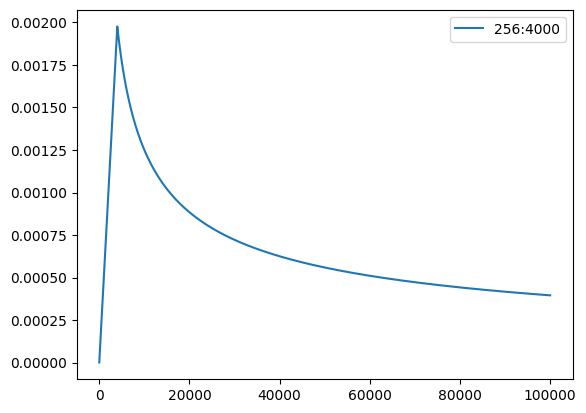

In [20]:
optimizer = NoamOpt(
    model_size=arch_args.encoder_embed_dim, 
    factor=config.lr_factor, 
    warmup=config.lr_warmup, 
    optimizer=torch.optim.AdamW(model.parameters(), lr=0, betas=(0.9, 0.98), eps=1e-9, weight_decay=0.0001))
plt.plot(np.arange(1, 100000), [optimizer.rate(i) for i in range(1, 100000)])
plt.legend([f"{optimizer.model_size}:{optimizer.warmup}"])
None

# 訓練步驟

## Training 

In [21]:
from fairseq.data import iterators
from torch.cuda.amp import GradScaler, autocast

def train_one_epoch(epoch_itr, model, task, criterion, optimizer, accum_steps=1):
    itr = epoch_itr.next_epoch_itr(shuffle=True)
    itr = iterators.GroupedIterator(itr, accum_steps) # 梯度累積: 每 accum_steps 個 sample 更新一次
    
    stats = {"loss": []}
    scaler = GradScaler() # 混和精度訓練 automatic mixed precision (amp) 
    
    model.train()
    progress = tqdm.tqdm(itr, desc=f"train epoch {epoch_itr.epoch}", leave=False)
    for samples in progress:
        model.zero_grad()
        accum_loss = 0
        sample_size = 0
        # 梯度累積: 每 accum_steps 個 sample 更新一次
        for i, sample in enumerate(samples):
            if i == 1:
                # emptying the CUDA cache after the first step can reduce the chance of OOM
                torch.cuda.empty_cache()

            sample = utils.move_to_cuda(sample, device=device)
            target = sample["target"]
            sample_size_i = sample["ntokens"]
            sample_size += sample_size_i
            
            # 混和精度訓練 
            with autocast():
                net_output = model.forward(**sample["net_input"])
                lprobs = F.log_softmax(net_output[0], -1)            
                loss = criterion(lprobs.view(-1, lprobs.size(-1)), target.view(-1))
                
                # logging
                accum_loss += loss.item()
                # back-prop
                scaler.scale(loss).backward()                
        
        scaler.unscale_(optimizer)
        optimizer.multiply_grads(1 / (sample_size or 1.0)) # (sample_size or 1.0) handles the case of a zero gradient
        gnorm = nn.utils.clip_grad_norm_(model.parameters(), config.clip_norm) # 梯度裁剪 防止梯度爆炸
        
        scaler.step(optimizer)
        scaler.update()
        
        # logging
        loss_print = accum_loss/sample_size
        stats["loss"].append(loss_print)
        progress.set_postfix(loss=loss_print)
        if config.use_wandb:
            wandb.log({
                "train/loss": loss_print,
                "train/grad_norm": gnorm.item(),
                "train/lr": optimizer.rate(),
                "train/sample_size": sample_size,
            })
        
    loss_print = np.mean(stats["loss"])
    logger.info(f"training loss: {loss_print:.4f}")
    return stats

## Validation & Inference 檢驗和推論
為防止訓練發生過度擬合，每過一段時間要做一次檢測，計算模型在未看過的資料上的表現。
- 過程基本上和training一樣，另外加上 inference
- 檢驗完畢可順便儲存模型參數

In [22]:
# fairseq 的 beam search generator
# 給定模型和輸入序列，用 beam search 生成預測結果
sequence_generator = task.build_generator([model], config)

def decode(toks, dictionary):
    # 從 Tensor 轉成人看得懂的句子
    s = dictionary.string(
        toks.int().cpu(),
        config.post_process,
    )
    return s if s else "<unk>"

def inference_step(sample, model):
    gen_out = sequence_generator.generate([model], sample)
    srcs = []
    hyps = []
    refs = []
    for i in range(len(gen_out)):
        # 對於每個 sample, 收集輸入，輸出和參考答案
        srcs.append(decode(
            utils.strip_pad(sample["net_input"]["src_tokens"][i], task.source_dictionary.pad()), 
            task.source_dictionary,
        ))
        hyps.append(decode(
            gen_out[i][0]["tokens"], # 0 代表取出 beam 內分數第一的輸出結果
            task.target_dictionary,
        ))
        refs.append(decode(
            utils.strip_pad(sample["target"][i], task.target_dictionary.pad()), 
            task.target_dictionary,
        ))
    return srcs, hyps, refs

In [29]:
import shutil
import sacrebleu

def validate(model, task, criterion, log_to_wandb=True):
    logger.info('begin validation')
    itr = load_data_iterator(task, "valid", 1, config.max_tokens, config.num_workers).next_epoch_itr(shuffle=False)
    
    stats = {"loss":[], "bleu": 0, "srcs":[], "hyps":[], "refs":[]}
    srcs = []
    hyps = []
    refs = []
    
    model.eval()
    progress = tqdm.tqdm(itr, desc=f"validation", leave=False)
    with torch.no_grad():
        for i, sample in enumerate(progress):
            # validation loss
            sample = utils.move_to_cuda(sample, device=device)
            net_output = model.forward(**sample["net_input"])

            lprobs = F.log_softmax(net_output[0], -1)
            target = sample["target"]
            sample_size = sample["ntokens"]
            loss = criterion(lprobs.view(-1, lprobs.size(-1)), target.view(-1)) / sample_size
            progress.set_postfix(valid_loss=loss.item())
            stats["loss"].append(loss)
            
            # 進行推論
            s, h, r = inference_step(sample, model)
            srcs.extend(s)
            hyps.extend(h)
            refs.extend(r)
            
    tok = 'zh' if task.cfg.target_lang == 'zh' else '13a'
    stats["loss"] = torch.stack(stats["loss"]).mean().item()
    stats["bleu"] = sacrebleu.corpus_bleu(hyps, [refs], tokenize=tok) # 計算BLEU score
    stats["srcs"] = srcs
    stats["hyps"] = hyps
    stats["refs"] = refs
    
    if config.use_wandb and log_to_wandb:
        wandb.log({
            "valid/loss": stats["loss"],
            "valid/bleu": stats["bleu"].score,
        }, commit=False)
    
    showid = np.random.randint(len(hyps))
    logger.info("example source: " + srcs[showid])
    logger.info("example hypothesis: " + hyps[showid])
    logger.info("example reference: " + refs[showid])
    logger.info("example spectrums: ")
    #show_spec(hyps[showid], refs[showid])
    # show bleu results
    logger.info(f"validation loss:\t{stats['loss']:.4f}")
    logger.info(stats["bleu"].format())
    return stats

## Functions for calculating spectrum

In [23]:
from csv import DictReader#load Ag.txt for TMM

wl_ag = []
n_ag = []
k_ag = []
with open('Ag.txt', 'r') as csv_file:
    reader = DictReader(csv_file, delimiter='\t', fieldnames=['wavelength', 'n', 'k'])
    for i, line in enumerate(reader):
        if i != 0:
            wl_ag.append(float(line['wavelength']))
            n_ag.append(float(line['n']))
            k_ag.append(float(line['k']))
wl_ag = np.array(wl_ag)
wll = wl_ag / 1000
n_ag = np.array(n_ag)
k_ag = np.array(k_ag)

def n_al2o3(wl):#n = sqrt(1+X), wl:wavelength, ref:https://reurl.cc/g65Nqp, Sellmeier Eq
    nsq = 1 + 1.4313493*wl**2/(wl**2-0.0726631**2) + 0.65054713*wl**2/(wl**2-0.1193242**2) + 5.3414021*wl**2/(wl**2-18.028251**2)
    return np.sqrt(nsq)
def n_sio2(wl):
    nsq = 1 + 0.6961663*wl**2/(wl**2-0.0684043**2) + 0.4079426*wl**2/(wl**2-0.1162414**2) + 0.8974794*wl**2/(wl**2-9.896161**2)
    return np.sqrt(nsq)
def n_hfo2(wl):
    return 1.875 + 6.28e-3/(wl**2) + 5.8e-4/(wl**4)

In [24]:
import re
import numpy as np

def get_nd(data):
    # 原始字串
    data_str = data  # "a_12.3,h_20.2,l_34.5,s_23.3"

    # 提取浮點數列表 d(um)
    d = [float(x)/1000 for x in re.findall(r"\d+\.\d+", data_str)]
    # 定義字母對應到數字的映射
    mapping = {'a': 4, 'h': 2, 'l': 3, 's': 1}

    # 提取標籤並映射到對應的數字 nl
    labels = [x.split('_')[0] for x in data_str.split(',')]
    nl = [mapping[label] for label in labels]

    # 顯示結果
    #print("d =", d)   # [12.3, 20.2, 34.5, 23.3]
    #print("nl =", nl) # [4, 2, 3, 1]
    return nl, d


In [25]:
def Tr_M(nl, dl, k): #nl is index array, dl is thickness array, k is the wave vector of incoming wave.
    #normal incidence
    TI = np.array([[(nl[0]+1)/(2*nl[0]), (nl[0]-1)/(2*nl[0])], [(nl[0]-1)/(2*nl[0]), (nl[0]+1)/(2*nl[0])]])
    TD = np.array([[np.exp(1j*nl[0]*k*dl[0]),0],[0,np.exp(-1j*nl[0]*k*dl[0])]])
    TM = TD @ TI#total matrix for air to the first layer TD*TI
    for i, n in enumerate(nl):
        if (i+1) < len(nl):            
            n1 = n
            n2 = nl[i+1]
            d = dl[i+1]
            TI = np.array([[(n2+n1)/(2*n2), (n2-n1)/(2*n2)], [(n2-n1)/(2*n2), (n2+n1)/(2*n2)]])
            TD = np.array([[np.exp(1j*n2*k*d),0],[0,np.exp(-1j*n2*k*d)]])
            TM = (TD @ TI) @ TM
    n1 = nl[-1]
    n2 = 1
    TI = np.array([[(n2+n1)/(2*n2), (n2-n1)/(2*n2)], [(n2-n1)/(2*n2), (n2+n1)/(2*n2)]])
    TM = TI @ TM
    return -TM[1,0]/TM[1,1], TM[0,0] - TM[0,1]*TM[1,0]/TM[1,1]#r, t

In [26]:
def get_T(nl, dl):
    # Calculate transmission coefficients on GPU
    Tcl = []
    wll = wl_ag / 1000  # from Ag.txt

    for i, wl in enumerate(wll):
        nll = []
        for j in range(len(nl)):#get n(lambda) for each layer
            if nl[j] == 3:
                nll.append(n_al2o3(wl))
            elif nl[j] == 2:
                nll.append(n_hfo2(wl))
            elif nl[j] == 1:
                nll.append(n_sio2(wl))
            elif nl[j] == 4:
                nll.append(n_ag[i]+1j*k_ag[i])
        r, t = Tr_M(nll, dl, 2 * np.pi / wl)#coffs
        T = np.round(np.abs(t)**2 * 1000) / 1000  # Round to 3 decimal places
        Tcl.append(T)  # Move data back to CPU for saving and convert to scalar
    return Tcl

In [28]:
import matplotlib.pyplot as plt

def show_spec(hyp, ref):
    nlh, dlh = get_nd(hyp)
    nlr, dlr = get_nd(ref)
    Th = get_T(nlh, dlh)
    Tr = get_T(nlr, dlr)
    plt.xlim(0.25,2)
    plt.ylim(0,1)
    plt.plot(wll, Th, label = 'T_hyp')
    plt.plot(wll, Tr, label = 'T_ref')
    # Highlighting regions with background color
    plt.axvspan(0.4, 0.7, color='aqua', alpha=0.3)  # Visible region
    plt.axvspan(0.7, 2, color='pink', alpha=0.3)    # Infrared region
    # Adding labels for regions
    plt.text(0.55, 0.5, "Visible\nregion", color="orange", fontsize=12, ha='center')
    plt.text(1.35, 0.5, "Infrared\nregion", color="orange", fontsize=12, ha='center')

    plt.xlabel("wavelength($\mu$m)")
    plt.ylabel("Transmittance")
    plt.title("T_ref/T_hyp of the design")
    plt.legend()


# 儲存及載入模型參數

In [30]:
def validate_and_save(model, task, criterion, optimizer, epoch, save=True):   
    stats = validate(model, task, criterion)
    bleu = stats['bleu']
    loss = stats['loss']
    if save:
        # save epoch checkpoints
        savedir = Path(config.savedir).absolute()
        savedir.mkdir(parents=True, exist_ok=True)
        
        check = {
            "model": model.state_dict(),
            "stats": {"bleu": bleu.score, "loss": loss},
            "optim": {"step": optimizer._step}
        }
        torch.save(check, savedir/f"checkpoint{epoch}.pt")
        shutil.copy(savedir/f"checkpoint{epoch}.pt", savedir/f"checkpoint_last.pt")
        logger.info(f"saved epoch checkpoint: {savedir}/checkpoint{epoch}.pt")
    
        # save epoch samples
        with open(savedir/f"samples{epoch}.{config.source_lang}-{config.target_lang}.txt", "w") as f:
            for s, h in zip(stats["srcs"], stats["hyps"]):
                f.write(f"{s}\t{h}\n")

        # get best valid bleu    
        if getattr(validate_and_save, "best_bleu", 0) < bleu.score:
            validate_and_save.best_bleu = bleu.score
            torch.save(check, savedir/f"checkpoint_best.pt")
            
        del_file = savedir / f"checkpoint{epoch - config.keep_last_epochs}.pt"
        if del_file.exists():
            del_file.unlink()
    
    return stats

def try_load_checkpoint(model, optimizer=None, name=None):
    name = name if name else "checkpoint_last.pt"
    checkpath = Path(config.savedir)/name
    if checkpath.exists():
        check = torch.load(checkpath)
        model.load_state_dict(check["model"])
        stats = check["stats"]
        step = "unknown"
        if optimizer != None:
            optimizer._step = step = check["optim"]["step"]
        logger.info(f"loaded checkpoint {checkpath}: step={step} loss={stats['loss']} bleu={stats['bleu']}")
    else:
        logger.info(f"no checkpoints found at {checkpath}!")

# 主程式
## 訓練迴圈

In [31]:
model = model.to(device=device)
criterion = criterion.to(device=device)

In [32]:
!nvidia-smi

Fri Dec  6 19:52:24 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.99                 Driver Version: 555.99         CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   51C    P8              6W /   75W |     131MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [33]:
import torch
torch.cuda.empty_cache()


In [34]:
logger.info("task: {}".format(task.__class__.__name__))
logger.info("encoder: {}".format(model.encoder.__class__.__name__))
logger.info("decoder: {}".format(model.decoder.__class__.__name__))
logger.info("criterion: {}".format(criterion.__class__.__name__))
logger.info("optimizer: {}".format(optimizer.__class__.__name__))
logger.info(
    "num. model params: {:,} (num. trained: {:,})".format(
        sum(p.numel() for p in model.parameters()),
        sum(p.numel() for p in model.parameters() if p.requires_grad),
    )
)
logger.info(f"max tokens per batch = {config.max_tokens}, accumulate steps = {config.accum_steps}")

2024-12-06 19:52:28 | INFO | seq2seq | task: TranslationTask
2024-12-06 19:52:28 | INFO | seq2seq | encoder: TransformerEncoder
2024-12-06 19:52:28 | INFO | seq2seq | decoder: TransformerDecoder
2024-12-06 19:52:28 | INFO | seq2seq | criterion: LabelSmoothedCrossEntropyCriterion
2024-12-06 19:52:28 | INFO | seq2seq | optimizer: NoamOpt
2024-12-06 19:52:28 | INFO | seq2seq | num. model params: 15,156,224 (num. trained: 15,156,224)
2024-12-06 19:52:28 | INFO | seq2seq | max tokens per batch = 8192, accumulate steps = 2


In [151]:
epoch_itr = load_data_iterator(task, "train", config.start_epoch, config.max_tokens, config.num_workers)
try_load_checkpoint(model, optimizer, name=config.resume)
savedir = Path(config.savedir).absolute()
savedir.mkdir(parents=True, exist_ok=True)
with open(savedir / f"average traing loss and validation loss for every epoch.txt", "w") as f:
    while epoch_itr.next_epoch_idx <= config.max_epoch:
        # train for one epoch
        stats = train_one_epoch(epoch_itr, model, task, criterion, optimizer, config.accum_steps)
        avg_t_loss = np.mean(stats["loss"])
        stats = validate_and_save(model, task, criterion, optimizer, epoch=epoch_itr.epoch)
        avg_v_loss = stats["loss"]
        logger.info("end of epoch {}".format(epoch_itr.epoch))
        f.write(f"Epoch {epoch_itr.epoch}: average training loss = {avg_t_loss:.4f}, "
                f"average validation loss = {avg_v_loss:.4f}\n")    
        epoch_itr = load_data_iterator(task, "train", epoch_itr.next_epoch_idx, config.max_tokens, config.num_workers)

2024-12-04 18:51:01 | INFO | fairseq.tasks.fairseq_task | can_reuse_epoch_itr = True
2024-12-04 18:51:01 | INFO | fairseq.tasks.fairseq_task | reuse_dataloader = True
2024-12-04 18:51:01 | INFO | fairseq.tasks.fairseq_task | rebuild_batches = False
2024-12-04 18:51:01 | INFO | fairseq.tasks.fairseq_task | creating new batches for epoch 1
2024-12-04 18:51:01 | INFO | seq2seq | no checkpoints found at checkpoints\transformermm6_vocab=8000,EN=6,Ehead=8,DN=6, Dhead=8,emb_dim=1024\checkpoint_last.pt!
2024-12-04 18:51:08 | INFO | fairseq.data.iterators | grouped total_num_itrs = 5926


train epoch 1:   0%|          | 0/5926 [00:00<?, ?it/s]

2024-12-04 19:20:48 | INFO | seq2seq | training loss: 4.3239
2024-12-04 19:20:48 | INFO | seq2seq | begin validation
2024-12-04 19:20:48 | INFO | fairseq.tasks.fairseq_task | can_reuse_epoch_itr = True
2024-12-04 19:20:48 | INFO | fairseq.tasks.fairseq_task | reuse_dataloader = True
2024-12-04 19:20:48 | INFO | fairseq.tasks.fairseq_task | rebuild_batches = False
2024-12-04 19:20:48 | INFO | fairseq.tasks.fairseq_task | creating new batches for epoch 1


validation:   0%|          | 0/121 [00:00<?, ?it/s]

2024-12-04 19:22:39 | INFO | seq2seq | example source: 0.044,0.031,0.022,0.017,0.014,0.013,0.012,0.013,0.013,0.014,0.013,0.013,0.013,0.012,0.013,0.013,0.013,0.013,0.012,0.011,0.011,0.010,0.011,0.011,0.013,0.015,0.019,0.027,0.038,0.051,0.057,0.056,0.052,0.049,0.050,0.052,0.056,0.058,0.058,0.058,0.058,0.059,0.062,0.067,0.075,0.085,0.095,0.106,0.119,0.138,0.166,0.214,0.281,0.354,0.383,0.380,0.412,0.477,0.514,0.436,0.320,0.248,0.216,0.215,0.241,0.293,0.350,0.376,0.355,0.322,0.299,0.294,0.308,0.335,0.350,0.336,0.305,0.277,0.263,0.265,0.279,0.300,0.327,0.361,0.415,0.495,0.574,0.559,0.423,0.291,0.216,0.183,0.178,0.188,0.188,0.144,0.088,0.054,0.035,0.023,0.015,0.008,0.004,0.002,0.001,0.001,0.001,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2024-12-04 19:22:39 | INFO | seq2seq | example hypothesis: a_10.9,s_103.9,a_11.8,s_103.9,a_14.4,l_57.2,a_10.3,l_32.3
2024-12-04 19:22:39 | INFO | seq2seq | example reference: l_43.1,h_116.4,a_13.4,s_85.8,a_17.2,h_27.3,s

...

2024-12-05 09:54:41 | INFO | seq2seq | example source: 0.019,0.015,0.011,0.009,0.009,0.009,0.010,0.013,0.019,0.028,0.037,0.039,0.036,0.034,0.032,0.032,0.031,0.030,0.030,0.031,0.033,0.036,0.040,0.043,0.043,0.040,0.035,0.031,0.029,0.028,0.029,0.032,0.037,0.042,0.048,0.052,0.053,0.051,0.048,0.045,0.043,0.040,0.037,0.037,0.037,0.039,0.042,0.048,0.058,0.076,0.105,0.149,0.206,0.263,0.287,0.253,0.205,0.160,0.125,0.105,0.095,0.095,0.104,0.127,0.174,0.264,0.403,0.531,0.512,0.413,0.337,0.301,0.306,0.344,0.367,0.298,0.188,0.111,0.070,0.049,0.038,0.033,0.030,0.031,0.034,0.043,0.058,0.080,0.090,0.074,0.051,0.035,0.027,0.023,0.021,0.022,0.027,0.038,0.067,0.159,0.314,0.141,0.055,0.029,0.018,0.013,0.009,0.006,0.004,0.002,0.001,0.001,0.001,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2024-12-05 09:54:41 | INFO | seq2seq | example hypothesis: a_19.9,s_14.5,a_11.3,h_63.0,s_20.2,h_68.2,a_19.9,l_113.1,h_107.8,s_89.2,l_56.0
2024-12-05 09:54:41 | INFO | seq2seq | example reference: l_79.5,s_62.1,h_119.1,s

train epoch 30:   0%|          | 0/5926 [00:00<?, ?it/s]

2024-12-05 10:23:36 | INFO | seq2seq | training loss: 3.5592
2024-12-05 10:23:36 | INFO | seq2seq | begin validation
2024-12-05 10:23:36 | INFO | fairseq.tasks.fairseq_task | can_reuse_epoch_itr = True


validation:   0%|          | 0/121 [00:00<?, ?it/s]

2024-12-05 10:25:38 | INFO | seq2seq | example source: 0.043,0.045,0.050,0.055,0.060,0.064,0.066,0.067,0.065,0.061,0.054,0.048,0.041,0.035,0.031,0.027,0.024,0.022,0.021,0.020,0.019,0.019,0.018,0.018,0.018,0.017,0.017,0.017,0.016,0.016,0.016,0.015,0.015,0.014,0.014,0.014,0.013,0.013,0.013,0.014,0.015,0.016,0.018,0.021,0.025,0.031,0.038,0.048,0.062,0.083,0.112,0.155,0.211,0.283,0.366,0.438,0.483,0.451,0.365,0.278,0.214,0.176,0.154,0.142,0.141,0.151,0.170,0.195,0.236,0.301,0.391,0.470,0.468,0.385,0.286,0.214,0.169,0.143,0.131,0.132,0.147,0.182,0.254,0.386,0.480,0.330,0.170,0.090,0.053,0.034,0.024,0.018,0.014,0.011,0.009,0.008,0.007,0.006,0.006,0.006,0.006,0.006,0.006,0.006,0.007,0.010,0.015,0.029,0.071,0.042,0.010,0.003,0.001,0.001,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2024-12-05 10:25:38 | INFO | seq2seq | example hypothesis: h_30.3,s_39.8,a_19.5,h_56.7,a_19.9,s_107.1,h_23.0,l_118.8,a_19.9,s_50.1,l_39.6,s_60.5
2024-12-05 10:25:38 | INFO | seq2seq | example reference: s_13.3,h_27.4,l_

In [1]:
epoch_itr = load_data_iterator(task, "train", config.start_epoch, config.max_tokens, config.num_workers)
try_load_checkpoint(model, optimizer, name=config.resume)
savedir = Path(config.savedir).absolute()
savedir.mkdir(parents=True, exist_ok=True)
with open(savedir / f"average traing loss and validation loss for every epoch2.txt", "w") as f:
    while epoch_itr.next_epoch_idx <= config.max_epoch:
        # train for one epoch
        stats = train_one_epoch(epoch_itr, model, task, criterion, optimizer, config.accum_steps)
        avg_t_loss = np.mean(stats["loss"])
        stats = validate_and_save(model, task, criterion, optimizer, epoch=epoch_itr.epoch)
        avg_v_loss = stats["loss"]
        logger.info("end of epoch {}".format(epoch_itr.epoch))
        f.write(f"Epoch {epoch_itr.epoch+30}: average training loss = {avg_t_loss:.4f}, "
                f"average validation loss = {avg_v_loss:.4f}\n")    
        epoch_itr = load_data_iterator(task, "train", epoch_itr.next_epoch_idx, config.max_tokens, config.num_workers)

NameError: name 'load_data_iterator' is not defined

# 使用 average_checkpoints.py 將最後5個epoch的weight平均輸出為avg_last_5_checkpoint.pt

In [154]:
# 把幾個 checkpoint 平均起來可以達到 ensemble 的效果 #將file_io從fairseq移動到scripts 
checkdir="./checkpoints/transformermm6_vocab=8000,EN=6,Ehead=8,DN=6,Dhead=8,emb_dim=1024"#config.savedir
!python ./scripts/average_checkpoints.py \
--inputs {checkdir} \
--num-epoch-checkpoints 5 \
--output {checkdir}/avg_last_5_checkpoint.pt

Namespace(inputs=['./checkpoints/transformermm6_vocab=8000,EN=6,Ehead=8,DN=6,Dhead=8,emb_dim=1024'], output='./checkpoints/transformermm6_vocab=8000,EN=6,Ehead=8,DN=6,Dhead=8,emb_dim=1024/avg_last_5_checkpoint.pt', num_epoch_checkpoints=5, num_update_checkpoints=None, num_best_checkpoints=0, checkpoint_upper_bound=None)
averaging checkpoints:  ['./checkpoints/transformermm6_vocab=8000,EN=6,Ehead=8,DN=6,Dhead=8,emb_dim=1024\\checkpoint30.pt', './checkpoints/transformermm6_vocab=8000,EN=6,Ehead=8,DN=6,Dhead=8,emb_dim=1024\\checkpoint29.pt', './checkpoints/transformermm6_vocab=8000,EN=6,Ehead=8,DN=6,Dhead=8,emb_dim=1024\\checkpoint28.pt', './checkpoints/transformermm6_vocab=8000,EN=6,Ehead=8,DN=6,Dhead=8,emb_dim=1024\\checkpoint27.pt', './checkpoints/transformermm6_vocab=8000,EN=6,Ehead=8,DN=6,Dhead=8,emb_dim=1024\\checkpoint26.pt']
Finished writing averaged checkpoint to ./checkpoints/transformermm6_vocab=8000,EN=6,Ehead=8,DN=6,Dhead=8,emb_dim=1024/avg_last_5_checkpoint.pt


## 使用avg_last_5_checkpoint.pt的參數進行預測

In [35]:
# avg_last_5_checkpoint.pt: 最5後個檔案平均
try_load_checkpoint(model, name="avg_last_5_checkpoint.pt")
validate(model, task, criterion, log_to_wandb=False)
None

2024-12-06 19:53:05 | INFO | seq2seq | loaded checkpoint checkpoints\transformermm6_vocab=8000,EN=6,Ehead=8,DN=6,Dhead=8,emb_dim=1024\avg_last_5_checkpoint.pt: step=unknown loss=3.541916608810425 bleu=16.126655690349043
2024-12-06 19:53:05 | INFO | seq2seq | begin validation
2024-12-06 19:53:05 | INFO | fairseq.tasks.fairseq_task | can_reuse_epoch_itr = True
2024-12-06 19:53:05 | INFO | fairseq.tasks.fairseq_task | reuse_dataloader = True
2024-12-06 19:53:05 | INFO | fairseq.tasks.fairseq_task | rebuild_batches = False
2024-12-06 19:53:05 | INFO | fairseq.tasks.fairseq_task | creating new batches for epoch 1


validation:   0%|          | 0/121 [00:00<?, ?it/s]

c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\torch\nn\functional.py:5076: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
2024-12-06 19:55:23 | INFO | seq2seq | example source: 0.044,0.031,0.022,0.017,0.014,0.013,0.012,0.013,0.013,0.014,0.013,0.013,0.013,0.012,0.013,0.013,0.013,0.013,0.012,0.011,0.011,0.010,0.011,0.011,0.013,0.015,0.019,0.027,0.038,0.051,0.057,0.056,0.052,0.049,0.050,0.052,0.056,0.058,0.058,0.058,0.058,0.059,0.062,0.067,0.075,0.085,0.095,0.106,0.119,0.138,0.166,0.214,0.281,0.354,0.383,0.380,0.412,0.477,0.514,0.436,0.320,0.248,0.216,0.215,0.241,0.293,0.350,0.376,0.355,0.322,0.299,0.294,0.308,0.335,0.350,0.336,0.305,0.277,0.263,0.265,0.279,0.300,0.327,0.361,0.415,0.495,0.574,0.559,0.423,0.291,0.216,0.183,0.178,0.188,0.188,0.144,0.088,0.054,0.035,0.023,0.015,0.008,0.004,0.002,0.001,0.001,0.001,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,

In [36]:
def generate_prediction(model, task, split="test", outfile="./testmm6_prediction_6868.txt"):    
    task.load_dataset(split=split, epoch=1)
    itr = load_data_iterator(task, split, 1, config.max_tokens, config.num_workers).next_epoch_itr(shuffle=False)
    
    idxs = []
    hyps = []
    srcs = []

    model.eval()
    progress = tqdm.tqdm(itr, desc=f"prediction")
    with torch.no_grad():
        for i, sample in enumerate(progress):
            # validation loss
            sample = utils.move_to_cuda(sample, device=device)

            # 進行推論
            s, h, r = inference_step(sample, model)
            
            hyps.extend(h)
            srcs.extend(s)
            idxs.extend(list(sample['id']))
            
    # 根據 preprocess 時的順序排列
    hyps = [x for _,x in sorted(zip(idxs,hyps))]
    srcs = [x for _,x in sorted(zip(idxs,srcs))]
    
    with open(outfile, "w") as f:
        for h, s in zip(hyps, srcs):  # 將 hyps 和 srcs 配對
            f.write(h + "\n")        # 寫入 hypothesis
            
            f.write(s + "\n")        # 寫入 source


In [37]:
generate_prediction(model, task)

2024-12-06 19:55:23 | INFO | fairseq.data.data_utils | loaded 10,000 examples from: ./data-binmm6\test.src-tgt.src
2024-12-06 19:55:23 | INFO | fairseq.data.data_utils | loaded 10,000 examples from: ./data-binmm6\test.src-tgt.tgt
2024-12-06 19:55:23 | INFO | fairseq.tasks.translation | ./data-binmm6 test src-tgt 10000 examples
2024-12-06 19:55:23 | INFO | fairseq.tasks.fairseq_task | can_reuse_epoch_itr = True
2024-12-06 19:55:23 | INFO | fairseq.tasks.fairseq_task | reuse_dataloader = True
2024-12-06 19:55:23 | INFO | fairseq.tasks.fairseq_task | rebuild_batches = False
2024-12-06 19:55:23 | INFO | fairseq.tasks.fairseq_task | creating new batches for epoch 1


prediction:   0%|          | 0/121 [00:00<?, ?it/s]

# 查看.pt檔存了什麼東西

In [58]:
name = "avg_last_5_checkpoint.pt"      
checkpath = Path(config.savedir)/name
check = torch.load(checkpath)
print(check.keys())
print(check["model"].keys())
print(check["stats"].keys())
print(check["optim"].keys())
print(check["stats"]['loss'])

dict_keys(['model', 'stats', 'optim'])
odict_keys(['encoder.version', 'encoder.embed_tokens.weight', 'encoder.layers.0.self_attn.k_proj.weight', 'encoder.layers.0.self_attn.k_proj.bias', 'encoder.layers.0.self_attn.v_proj.weight', 'encoder.layers.0.self_attn.v_proj.bias', 'encoder.layers.0.self_attn.q_proj.weight', 'encoder.layers.0.self_attn.q_proj.bias', 'encoder.layers.0.self_attn.out_proj.weight', 'encoder.layers.0.self_attn.out_proj.bias', 'encoder.layers.0.self_attn_layer_norm.weight', 'encoder.layers.0.self_attn_layer_norm.bias', 'encoder.layers.0.fc1.weight', 'encoder.layers.0.fc1.bias', 'encoder.layers.0.fc2.weight', 'encoder.layers.0.fc2.bias', 'encoder.layers.0.final_layer_norm.weight', 'encoder.layers.0.final_layer_norm.bias', 'encoder.layers.1.self_attn.k_proj.weight', 'encoder.layers.1.self_attn.k_proj.bias', 'encoder.layers.1.self_attn.v_proj.weight', 'encoder.layers.1.self_attn.v_proj.bias', 'encoder.layers.1.self_attn.q_proj.weight', 'encoder.layers.1.self_attn.q_proj.

In [59]:
names = [f"checkpoint{i}.pt" for i in range(13, 18)]
for i in range(len(names)):
    name = names[i]    
    checkpath = Path(config.savedir)/name
    check = torch.load(checkpath)
    print(check.keys())
    print(check["model"].keys())
    print(check["stats"].keys())
    print(check["optim"].keys())
    print(check["stats"]['loss'])

dict_keys(['model', 'stats', 'optim'])
odict_keys(['encoder.version', 'encoder.embed_tokens.weight', 'encoder.layers.0.self_attn.k_proj.weight', 'encoder.layers.0.self_attn.k_proj.bias', 'encoder.layers.0.self_attn.v_proj.weight', 'encoder.layers.0.self_attn.v_proj.bias', 'encoder.layers.0.self_attn.q_proj.weight', 'encoder.layers.0.self_attn.q_proj.bias', 'encoder.layers.0.self_attn.out_proj.weight', 'encoder.layers.0.self_attn.out_proj.bias', 'encoder.layers.0.self_attn_layer_norm.weight', 'encoder.layers.0.self_attn_layer_norm.bias', 'encoder.layers.0.fc1.weight', 'encoder.layers.0.fc1.bias', 'encoder.layers.0.fc2.weight', 'encoder.layers.0.fc2.bias', 'encoder.layers.0.final_layer_norm.weight', 'encoder.layers.0.final_layer_norm.bias', 'encoder.layers.1.self_attn.k_proj.weight', 'encoder.layers.1.self_attn.k_proj.bias', 'encoder.layers.1.self_attn.v_proj.weight', 'encoder.layers.1.self_attn.v_proj.bias', 'encoder.layers.1.self_attn.q_proj.weight', 'encoder.layers.1.self_attn.q_proj.